### STEP 1: DOWNLOAD AND CLEAN PROJECT GUTENBERG BOOKS

Objective

- To download multiple public-domain books from Project Gutenberg, remove the Gutenberg header/footer (boilerplate text), combine all books into one large corpus, and save it as corpus_raw.txt inside A2/data/.

In [1]:
import os

# ---- Windows OpenMP crash workaround ----
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

### About dataset
The textual data used in this project is obtained from Project Gutenberg, a digital library that provides free access to books that are in the public domain. The dataset consists of the plain-text version of a literary book, downloaded using its official Gutenberg book ID. Each downloaded file originally contains front-matter and end-matter such as licensing information, publication notes, and Project Gutenberg metadata. For NLP suitability, only the main body of the book is retained by removing the header and footer using the official START and END OF PROJECT GUTENBERG EBOOK markers. The resulting dataset contains continuous, well-formed natural language text with preserved paragraph structure, making it appropriate for tasks such as tokenization, language modeling, and text generation.

#### STEP 1.1: Import Required Libraries

In [2]:
import re
import time
import requests

Explanation

- requests → downloads book text from the internet
- re → helps locate Gutenberg START/END markers using patterns
- time → adds a small delay so we don’t overload the server

#### STEP 1.2: Define a Function to Download and Remove Gutenberg Boilerplate

In [3]:
def fetch_gutenberg_text(book_id: int, timeout: int = 30) -> str:
    """
    Download a Project Gutenberg book by its ID and remove the header/footer
    using the official START/END markers.

    Parameters:
    - book_id : Gutenberg book number (e.g., 1342 for Pride & Prejudice)
    - timeout : request timeout in seconds

    Returns:
    - Cleaned main text of the book as a string
    """
    # Gutenberg plain text URL format
    url = f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt"

    # Download the text
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()  # raises an error if download fails
    raw = response.text

    # Patterns to find the real book content region
    # These markers vary slightly ("THIS" vs "THE"), so we handle both.
    start_pattern = r"\*\*\*\s*START OF (THIS|THE) PROJECT GUTENBERG EBOOK.*?\*\*\*"
    end_pattern   = r"\*\*\*\s*END OF (THIS|THE) PROJECT GUTENBERG EBOOK.*?\*\*\*"

    # Search for markers (DOTALL allows '.' to match newlines)
    start_match = re.search(start_pattern, raw, flags=re.IGNORECASE | re.DOTALL)
    end_match   = re.search(end_pattern, raw,   flags=re.IGNORECASE | re.DOTALL)

    # If markers are found, slice out only the main content
    if start_match and end_match and end_match.start() > start_match.end():
        raw = raw[start_match.end():end_match.start()]

    # Light whitespace normalization (keep paragraph breaks)
    raw = raw.replace("\r\n", "\n").replace("\r", "\n")  # unify newlines
    raw = re.sub(r"[ \t]+", " ", raw)                   # collapse repeated spaces/tabs
    raw = re.sub(r"\n{3,}", "\n\n", raw)                # collapse many blank lines

    return raw.strip()


#### STEP 1.3: Choose More Books to Make the Dataset Robust

In [4]:
# A larger set of classic English books (public-domain)
# You can add more IDs later to increase dataset size.
book_ids = [
    11,    # Alice's Adventures in Wonderland
    1342,  # Pride and Prejudice
    84,    # Frankenstein
    1661,  # The Adventures of Sherlock Holmes
    98,    # A Tale of Two Cities
    2701,  # Moby-Dick
    74,    # The Adventures of Tom Sawyer
    1400,  # Great Expectations
    174,   # The Picture of Dorian Gray
    345,   # Dracula
]


#### STEP 1.4: Download All Books and Combine into One Corpus

In [5]:
def build_corpus(book_ids, sleep_seconds: float = 0.5) -> str:
    """
    Download and clean multiple Gutenberg books, then combine them into one corpus.

    Parameters:
    - book_ids       : list of Gutenberg book IDs
    - sleep_seconds  : delay between downloads (polite to server)

    Returns:
    - A single combined text corpus
    """
    texts = []

    for idx, book_id in enumerate(book_ids, start=1):
        try:
            # Download and clean one book
            book_text = fetch_gutenberg_text(book_id)
            texts.append(book_text)

            # Print progress for monitoring
            print(f"[{idx}/{len(book_ids)}] Book {book_id} downloaded: {len(book_text):,} characters")

        except Exception as e:
            # If one book fails, continue with others (robustness)
            print(f"[{idx}/{len(book_ids)}] Book {book_id} FAILED: {e}")

        # Small delay to avoid rapid repeated requests
        time.sleep(sleep_seconds)

    # Join books with blank lines between them
    return "\n\n".join(texts)


#### STEP 1.5: Create the Corpus and Preview It

In [6]:
# Build the combined corpus
corpus_text = build_corpus(book_ids, sleep_seconds=0.5)

# Basic checks
print("\nTOTAL CHARACTERS IN CORPUS:", len(corpus_text))
print("\nSAMPLE TEXT (first 800 characters):\n")
print(corpus_text[:800])


[1/10] Book 11 downloaded: 144,013 characters
[2/10] Book 1342 downloaded: 721,387 characters
[3/10] Book 84 downloaded: 419,141 characters
[4/10] Book 1661 downloaded: 561,851 characters
[5/10] Book 98 downloaded: 756,960 characters
[6/10] Book 2701 downloaded: 1,218,168 characters
[7/10] Book 74 downloaded: 392,395 characters
[8/10] Book 1400 downloaded: 994,337 characters
[9/10] Book 174 downloaded: 429,196 characters
[10/10] Book 345 downloaded: 840,765 characters

TOTAL CHARACTERS IN CORPUS: 6478231

SAMPLE TEXT (first 800 characters):

[Illustration]

Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I. Down the Rabbit-Hole
 CHAPTER II. The Pool of Tears
 CHAPTER III. A Caucus-Race and a Long Tale
 CHAPTER IV. The Rabbit Sends in a Little Bill
 CHAPTER V. Advice from a Caterpillar
 CHAPTER VI. Pig and Pepper
 CHAPTER VII. A Mad Tea-Party
 CHAPTER VIII. The Queen’s Croquet-Ground
 CHAPTER IX. The Mock Turtle’s Story
 CHAPTER

#### STEP 1.6: Save the Raw Corpus

In [7]:
import os

# Define the save path explicitly (parallel to main/)
RAW_CORPUS_PATH = "../data/corpus_raw.txt"
# Ensure the data folder exists
os.makedirs("../data", exist_ok=True)

# Write the combined text corpus to disk
with open(RAW_CORPUS_PATH, "w", encoding="utf-8") as f:
    f.write(corpus_text)

print("Saved raw corpus to:", os.path.abspath(RAW_CORPUS_PATH))


Saved raw corpus to: d:\Data Science\Second Semester\NLP\Assignment\A2\data\corpus_raw.txt


### STEP 2: TEXT NORMALIZATION AND STANDARDIZATION

Objective

- To load the saved raw corpus (corpus_raw.txt), normalize messy Unicode characters (quotes, dashes, ellipses), standardize spacing/newlines, and save a clean version (corpus_clean.txt) for reliable tokenization and vocabulary building.

#### STEP 2.1: Define File Paths (Raw → Clean)

In [8]:
import os

DATA_DIR = "../data"
os.makedirs(DATA_DIR, exist_ok=True)

RAW_CORPUS_PATH   = os.path.join(DATA_DIR, "corpus_raw.txt")
CLEAN_CORPUS_PATH = os.path.join(DATA_DIR, "corpus_clean.txt")

print("RAW_CORPUS_PATH  =", os.path.abspath(RAW_CORPUS_PATH))
print("CLEAN_CORPUS_PATH=", os.path.abspath(CLEAN_CORPUS_PATH))


RAW_CORPUS_PATH  = d:\Data Science\Second Semester\NLP\Assignment\A2\data\corpus_raw.txt
CLEAN_CORPUS_PATH= d:\Data Science\Second Semester\NLP\Assignment\A2\data\corpus_clean.txt


#### STEP 2.2: Load the Raw Corpus from Disk

In [9]:
# Read the raw corpus text from file
with open(RAW_CORPUS_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Raw corpus loaded.")
print("Total characters (raw):", len(raw_text))
print("\nSample (raw):\n")
print(raw_text[:500])

Raw corpus loaded.
Total characters (raw): 6478231

Sample (raw):

[Illustration]

Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I. Down the Rabbit-Hole
 CHAPTER II. The Pool of Tears
 CHAPTER III. A Caucus-Race and a Long Tale
 CHAPTER IV. The Rabbit Sends in a Little Bill
 CHAPTER V. Advice from a Caterpillar
 CHAPTER VI. Pig and Pepper
 CHAPTER VII. A Mad Tea-Party
 CHAPTER VIII. The Queen’s Croquet-Ground
 CHAPTER IX. The Mock Turtle’s Story
 CHAPTER X. The Lobster Quadrille
 CHAPTER XI. Who Stole


#### STEP 2.3.1: Define a Function to Remove Front Matter

In [10]:
import re

def remove_front_matter(text: str) -> str:
    """
    Remove front matter (title page, author, contents)
    AND remove the first chapter heading and chapter title.

    Result:
    - Text starts directly with narrative prose.
    """

    # Pattern to locate the FIRST chapter heading
    chapter_start_pattern = (
        r"(?im)"                 # ignore case, multiline
        r"^\s*chapter\s+"        # 'CHAPTER' or 'Chapter'
        r"(?:[ivxlcdm]+|\d+)"    # Roman numerals or digits
        r"\s*\.?\s*$"            # optional period
    )

    match = re.search(chapter_start_pattern, text)
    if not match:
        return text.strip()

    # Cut text starting from chapter heading
    text = text[match.end():]

    # Remove the chapter title line (usually comes right after)
    # Example: "Down the Rabbit-Hole"
    text = re.sub(
        r"(?m)^\s*[A-Za-z][A-Za-z \-']{0,60}\s*$",
        "",
        text,
        count=1
    )

    # Clean up excessive blank lines
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


#### STEP 2.3.2: Apply Front-Matter Removal

In [11]:
text_no_front = remove_front_matter(raw_text)

print("Front matter removed.")
print("Total characters (after removal):", len(text_no_front))
print("\nSample after removal:\n")
print(text_no_front[:500])


Front matter removed.
Total characters (after removal): 6477654

Sample after removal:

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”

So she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy and stupid), whether the pleasure of
making a daisy-chain would be worth the trouble of gett


### STEP 2.4: UNICODE NORMALIZATION AND TEXT STANDARDIZATION

#### STEP 2.4.1: Define the Normalization Function

In [12]:
import re

def normalize_text(text: str) -> str:
    """
    Normalize and standardize text for language model training.

    This function:
    1) Converts smart quotes to normal quotes
    2) Converts long dashes to '-'
    3) Converts ellipsis to '...'
    4) Removes invisible characters (BOM, zero-width spaces)
    5) Removes chapter headings and chapter titles
    6) Removes decorative separators (e.g., * * * * *)
    7) Standardizes whitespace and newlines
    """

    # --- 1) Normalize quotes ---
    text = (text.replace("“", '"').replace("”", '"')
                .replace("‘", "'").replace("’", "'"))

    # --- 2) Normalize dashes ---
    text = text.replace("—", "-").replace("–", "-")

    # --- 3) Normalize ellipsis ---
    text = text.replace("…", "...")

    # --- 4) Remove invisible characters ---
    text = text.replace("\ufeff", "")   # Byte Order Mark
    text = text.replace("\u200b", "")   # zero-width space

    # --- 5) Normalize newlines across OS ---
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # --- 6) Remove chapter headings (extra safety) ---
    # Examples removed:
    # CHAPTER I
    # Chapter 12.
    text = re.sub(
        r"(?im)^\s*chapter\s+(?:[ivxlcdm]+|\d+)\s*\.?\s*$",
        "",
        text
    )

    # --- 7) Remove chapter title lines ---
    # Example:
    # Down the Rabbit-Hole
    text = re.sub(
        r"(?m)^\s*[A-Za-z][A-Za-z \-']{0,60}\s*$",
        "",
        text
    )

    # --- 8) Remove decorative separators ---
    # Examples:
    # * * * * *
    # ********
    # ------
    text = re.sub(
        r"(?m)^\s*([*\-•_]\s*){3,}$",
        "",
        text
    )

    # --- 9) Remove symbol-only lines ---
    text = re.sub(
        r"(?m)^\s*[^A-Za-z0-9\s]{3,}\s*$",
        "",
        text
    )

    # --- 10) Standardize whitespace ---
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


#### STEP 2.4.2: Apply Normalization and Preview Results

In [13]:
# Normalize the narrative-only text (front matter already removed)
clean_text = normalize_text(text_no_front)

print("Normalization completed.")
print("Total characters (clean):", len(clean_text))

print("\nSample (clean):\n")
print(clean_text[:500])


Normalization completed.
Total characters (clean): 6448724

Sample (clean):

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, "and what is the use of a book," thought Alice
"without pictures or conversations?"

So she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy and stupid), whether the pleasure of
making a daisy-chain would be worth the trouble of gett


#### STEP 2.5: Save the Clean Corpus

In [14]:
# Ensure data folder exists (safe to call again)
os.makedirs("../data", exist_ok=True)

# Save cleaned corpus to disk
with open(CLEAN_CORPUS_PATH, "w", encoding="utf-8") as f:
    f.write(clean_text)

print("Saved clean corpus to:", os.path.abspath(CLEAN_CORPUS_PATH))


Saved clean corpus to: d:\Data Science\Second Semester\NLP\Assignment\A2\data\corpus_clean.txt


### STEP 3: TOKENIZATION FOR LSTM LANGUAGE MODEL

Objective
- To convert the final cleaned corpus text into a sequence of word-level tokens (words, numbers, punctuation).
- These tokens will be used in the next step to build the vocabulary (stoi, itos) and train the LSTM language model.

#### STEP 3.1: Load the CLEAN CORPUS and Apply Cleaning Pipeline

In [15]:
# STEP 3.1: Load the FINAL cleaned corpus from STEP 2
CLEAN_CORPUS_PATH = "../data/corpus_clean.txt"

with open(CLEAN_CORPUS_PATH, "r", encoding="utf-8") as f:
    clean_text = f.read()

print("Clean corpus loaded.")
print("Total characters:", len(clean_text))
print("\nSample:\n")
print(clean_text[:300])


Clean corpus loaded.
Total characters: 6448724

Sample:

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, "and what is the use of a book," thought Alice
"without pictures or conversations


#### STEP 3.2: WORD-LEVEL TOKENIZATION

In [16]:
import re

def word_tokenize(text: str):
    """
    Tokenize clean text into words, numbers, and punctuation
    for LSTM language modeling.
    """
    text = text.lower()
    tokens = re.findall(r"[a-z]+(?:'[a-z]+)?|[0-9]+|[^\w\s]", text)
    return tokens


Why word-level tokenization ?

- Easier to understand and debug than subword tokenization
- Traditional and effective for LSTM language models
- Matches classic NLP assignments and exams

#### STEP 3.3: Tokenize the Entire Corpus

In [17]:
tokens = word_tokenize(clean_text)

print("Tokenization completed.")
print("Total tokens:", len(tokens))
print("\nFirst 50 tokens:\n")
print(tokens[:50])


Tokenization completed.
Total tokens: 1428333

First 50 tokens:

['alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by', 'her', 'sister', 'on', 'the', 'bank', ',', 'and', 'of', 'having', 'nothing', 'to', 'do', ':', 'once', 'or', 'twice', 'she', 'had', 'peeped', 'into', 'the', 'book', 'her', 'sister', 'was', 'reading', ',', 'but', 'it', 'had', 'no', 'pictures', 'or', 'conversations', 'in', 'it', ',', '"', 'and', 'what']


#### STEP 3.4: TOKEN STATISTICS

In [18]:
from collections import Counter

token_counts = Counter(tokens)

print("Unique tokens:", len(token_counts))
print("\nMost common tokens:")
for tok, freq in token_counts.most_common(10):
    print(f"{tok:>10} : {freq}")


Unique tokens: 31043

Most common tokens:
         , : 95887
       the : 62011
         . : 57563
       and : 40336
         " : 37567
        of : 31859
        to : 31644
         i : 26039
         a : 24862
        in : 19675


#### STEP 3.5: SAVE TOKENS TO DATA FOLDER

#### STEP 3.5.1: Save Tokens as a Text File (One Token per Space)

In [19]:
# Path to the cleaned corpus file (now repurposed to store tokens)
CLEAN_CORPUS_PATH = "../data/corpus_clean.txt"

# Save tokens as a space-separated sequence
# Each space-separated unit represents one token
with open(CLEAN_CORPUS_PATH, "w", encoding="utf-8") as f:
    f.write(" ".join(tokens))

print("Tokenized corpus saved to:", CLEAN_CORPUS_PATH)


Tokenized corpus saved to: ../data/corpus_clean.txt


### STEP 4: VOCABULARY CONSTRUCTION (stoi / itos)
Objectives

- To build a vocabulary from your tokenized corpus and convert each token into an integer ID for training an LSTM language model.

This step creates:

1. itos = index → token
2. stoi = token → index
3. ids = token IDs (integer sequence)

#### STEP 4.1: Load Tokens from corpus_clean.txt

In [20]:
# STEP 4.1: Load tokens (space-separated) from file
TOKEN_PATH = "../data/corpus_clean.txt"

with open(TOKEN_PATH, "r", encoding="utf-8") as f:
    tokens = f.read().split()   # split() reconstructs the token list

print("Token file loaded.")
print("Total tokens:", len(tokens))
print("First 30 tokens:", tokens[:30])

Token file loaded.
Total tokens: 1428333
First 30 tokens: ['alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by', 'her', 'sister', 'on', 'the', 'bank', ',', 'and', 'of', 'having', 'nothing', 'to', 'do', ':', 'once', 'or', 'twice', 'she', 'had', 'peeped', 'into']


#### STEP 4.2: Define Special Tokens

In [21]:
# STEP 4.2: Define special tokens needed for training
specials = ["<pad>", "<unk>"]

# <pad> is used to pad sequences to equal length during batching
# <unk> is used when a token is not found in the vocabulary


#### STEP 4.3: Count Token Frequencies

In [22]:
from collections import Counter

# STEP 4.3: Count how often each token occurs
counter = Counter(tokens)

print("Unique tokens (before filtering):", len(counter))
print("Most common tokens:", counter.most_common(10))


Unique tokens (before filtering): 31043
Most common tokens: [(',', 95887), ('the', 62011), ('.', 57563), ('and', 40336), ('"', 37567), ('of', 31859), ('to', 31644), ('i', 26039), ('a', 24862), ('in', 19675)]


#### STEP 4.4: Build a Controlled Vocabulary (min_freq + max_vocab_size)

In [23]:
# STEP 4.4: Vocabulary configuration (adjustable)
min_freq = 2            # keep tokens appearing at least 2 times
max_vocab_size = 30000  # total vocab size INCLUDING specials

# Remove special tokens from the counter if they appear in data (safety)
for sp in specials:
    counter.pop(sp, None)

# Sort tokens by:
# 1) frequency (descending)
# 2) token name (ascending) for stable reproducible ordering
sorted_items = sorted(counter.items(), key=lambda x: (-x[1], x[0]))

# Apply minimum frequency threshold
sorted_items = [(tok, freq) for tok, freq in sorted_items if freq >= min_freq]

# Keep only the top tokens that fit in the vocabulary size limit
keep_n = max_vocab_size - len(specials)
vocab_tokens = [tok for tok, _ in sorted_items[:keep_n]]

# Build itos (index -> token)
itos = specials + vocab_tokens

# Build stoi (token -> index)
stoi = {tok: idx for idx, tok in enumerate(itos)}

print("Final vocabulary size:", len(itos))
print("First 20 vocab tokens:", itos[:20])


Final vocabulary size: 20130
First 20 vocab tokens: ['<pad>', '<unk>', ',', 'the', '.', 'and', '"', 'of', 'to', 'i', 'a', 'in', '-', 'that', 'it', 'was', 'he', 'his', ';', 'you']


#### STEP 4.5: Encode Tokens into Integer IDs

In [24]:
# STEP 4.5: Get indices for special tokens
PAD = stoi["<pad>"]
UNK = stoi["<unk>"]

def encode(token_list):
    """
    Convert tokens (strings) into ids (integers) using stoi.
    Tokens not in vocabulary are mapped to <unk>.
    """
    return [stoi.get(tok, UNK) for tok in token_list]

# Convert the entire corpus into integer IDs
ids = encode(tokens)

print("Encoding completed.")
print("First 30 ids:", ids[:30])
print("Example mapping:", tokens[0], "->", ids[0])


Encoding completed.
First 30 ids: [327, 15, 787, 8, 184, 71, 1333, 7, 563, 41, 29, 298, 32, 3, 965, 2, 5, 7, 238, 152, 8, 66, 80, 167, 57, 989, 37, 22, 4183, 72]
Example mapping: alice -> 327


END OF STEP 4 (Deliverable)

We now have:
- itos : list mapping index → token
- stoi : dict mapping token → index
- ids : integer sequence for training the LSTM LM

### STEP 5: CREATE TRAINING SEQUENCES (X → Y) FOR NEXT-TOKEN PREDICTION

#### STEP 5.1: Split the Corpus into Train and Validation Sets

In [25]:
# STEP 5.1: Train/validation split
split_ratio = 0.9  # 90% train, 10% validation
split_idx = int(len(ids) * split_ratio)

train_ids = ids[:split_idx]
valid_ids = ids[split_idx:]

print("Train tokens:", len(train_ids))
print("Valid tokens:", len(valid_ids))


Train tokens: 1285499
Valid tokens: 142834


Explanation
- Validation data is never used for training
- It measures generalization and overfitting

#### STEP 5.2: CONVERT SPLITS TO 1D TENSORS

In [26]:
import torch

# Convert token ID lists to 1D tensors
train_data_1d = torch.tensor(train_ids, dtype=torch.long)
valid_data_1d = torch.tensor(valid_ids, dtype=torch.long)

print("Train tensor shape:", train_data_1d.shape)
print("Valid tensor shape:", valid_data_1d.shape)


Train tensor shape: torch.Size([1285499])
Valid tensor shape: torch.Size([142834])


#### STEP 5.2: DEFINE THE get_batch FUNCTION
Objective
- Define a function that randomly samples subsequences from the token stream and returns (X, Y) pairs for next-token prediction during LSTM training.

In [27]:
import torch

def get_batch(data_1d, batch_size, seq_len, device):
    ix = torch.randint(0, len(data_1d) - seq_len - 1, (batch_size,))
    x = torch.stack([data_1d[i:i+seq_len] for i in ix])
    y = torch.stack([data_1d[i+1:i+seq_len+1] for i in ix])
    return x.to(device), y.to(device)


#### STEP 5.2.2: Sanity Check the Function

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 64
seq_len = 100

# Use training data
xb, yb = get_batch(train_data_1d, batch_size, seq_len, device)

print("X shape:", xb.shape)
print("Y shape:", yb.shape)

print("Decoded X sample:", [itos[i] for i in xb[0][:10].tolist()])
print("Decoded Y sample:", [itos[i] for i in yb[0][:10].tolist()])


X shape: torch.Size([64, 100])
Y shape: torch.Size([64, 100])
Decoded X sample: [',', 'nodding', 'pleasantly', 'to', 'him', 'across', 'the', 'table', '.', '"']
Decoded Y sample: ['nodding', 'pleasantly', 'to', 'him', 'across', 'the', 'table', '.', '"', 'do']


### STEP 6: BUILD THE LSTM LANGUAGE MODEL

Objective

To define an LSTM-based language model that learns to predict the next token given a sequence of previous tokens.

The model architecture:

- Embedding layer (token IDs → dense vectors)
- LSTM layer(s) (sequence modeling)
- Linear output layer (hidden states → vocabulary logits)

#### STEP 6.1: Import PyTorch Modules and Set Basic Parameters

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Vocabulary size = number of unique tokens in your vocab
vocab_size = len(itos)

print("Vocabulary size:", vocab_size)


Vocabulary size: 20130


#### STEP 6.2: Define the LSTM Language Model Class

In [30]:
class LSTMLanguageModel(nn.Module):
    """
    LSTM Language Model for next-token prediction.

    Input:  token IDs of shape [batch_size, seq_len]
    Output: logits of shape [batch_size, seq_len, vocab_size]
    """

    def __init__(self, vocab_size, emb_dim=256, hidden_dim=512, num_layers=2, dropout=0.2, pad_idx=0):
        super().__init__()

        # Embedding layer converts token IDs into dense vectors
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)

        # LSTM processes sequences of embeddings
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Output layer maps LSTM hidden states to vocabulary logits
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, state=None):
        """
        Forward pass.

        Parameters:
        - x     : [batch_size, seq_len] token IDs
        - state : optional (h0, c0) LSTM states

        Returns:
        - logits: [batch_size, seq_len, vocab_size]
        - state : updated LSTM states
        """
        # Convert token IDs to embeddings
        emb = self.embedding(x)  # [B, T, emb_dim]

        # Pass through LSTM
        out, state = self.lstm(emb, state)  # out: [B, T, hidden_dim]

        # Convert to logits over vocabulary
        logits = self.fc(out)  # [B, T, vocab_size]

        return logits, state


#### STEP 6.3: Create the Model Instance

In [31]:
# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# Model hyperparameters (you can tune these later)
emb_dim = 256
hidden_dim = 1024
num_layers = 3
dropout = 0.3

model = LSTMLanguageModel(
    vocab_size=vocab_size,
    emb_dim=emb_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout,
    pad_idx=PAD
).to(device)

print(model)
print("Model created on device:", device)


LSTMLanguageModel(
  (embedding): Embedding(20130, 256, padding_idx=0)
  (lstm): LSTM(256, 1024, num_layers=3, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=1024, out_features=20130, bias=True)
)
Model created on device: cuda


#### STEP 6.4: Test a Forward Pass Using get_batch

In [32]:
# Create a test batch from training data
batch_size = 32
seq_len = 100

xb, yb = get_batch(train_data_1d, batch_size, seq_len, device)

# Forward pass
logits, _ = model(xb)

print("Input shape (X):", xb.shape)
print("Logits shape:", logits.shape)


Input shape (X): torch.Size([32, 100])
Logits shape: torch.Size([32, 100, 20130])


### STEP 7: TRAINING LOOP + PLOT TRAINING & VALIDATION LOSS
Objective

- Train the LSTM language model using get_batch
- Track training loss and validation loss over time
- Plot both losses to visualize learning and overfitting

#### STEP 7.1: Define Loss Function and Optimizer

In [33]:
# STEP 7.2: Loss + optimizer
# CrossEntropyLoss expects class logits and target token IDs

loss_fn = nn.CrossEntropyLoss(ignore_index=PAD)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)


Explanation

- Cross-entropy is used because next-token prediction is a multi-class classification problem
- ignore_index=PAD avoids counting padding tokens (safe even if you don't use padding yet)

#### STEP 7.2: Define a Function to Estimate Validation Loss

In [34]:
@torch.no_grad()
def estimate_loss(data_1d, eval_iters=50):
    """
    Estimate average loss on a dataset by sampling eval_iters batches.
    """
    model.eval()
    losses = []

    for _ in range(eval_iters):
        xb, yb = get_batch(data_1d, batch_size, seq_len, device)
        logits, _ = model(xb)

        # Reshape logits and targets for CrossEntropyLoss
        B, T, V = logits.shape
        loss = loss_fn(logits.reshape(B*T, V), yb.reshape(B*T))
        losses.append(loss.item())

    model.train()
    return sum(losses) / len(losses)


#### STEP 7.3: Training Loop with Logging

In [36]:
# STEP 7.4: Training configuration
max_iters = 10000          # total training iterations
log_interval = 200        # record loss every N iterations
eval_iters = 10           # batches used to estimate validation loss
grad_clip = 1.0           # gradient clipping for stability

train_losses = []
valid_losses = []
steps = []

for it in range(1, max_iters + 1):
    # Get training batch
    xb, yb = get_batch(train_data_1d, batch_size, seq_len, device)

    # Forward pass
    logits, _ = model(xb)

    # Compute loss
    B, T, V = logits.shape
    loss = loss_fn(logits.reshape(B*T, V), yb.reshape(B*T))

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()

    # Gradient clipping helps prevent exploding gradients in RNNs
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

    optimizer.step()

    # Logging
    if it % log_interval == 0:
        val_loss = estimate_loss(valid_data_1d, eval_iters=eval_iters)

        steps.append(it)
        train_losses.append(loss.item())
        valid_losses.append(val_loss)

        print(f"Iter {it:4d} | Train Loss: {loss.item():.4f} | Valid Loss: {val_loss:.4f}")


Iter  200 | Train Loss: 6.3882 | Valid Loss: 6.3342
Iter  400 | Train Loss: 6.2385 | Valid Loss: 6.2307
Iter  600 | Train Loss: 6.0581 | Valid Loss: 6.0973
Iter  800 | Train Loss: 5.9247 | Valid Loss: 6.0098
Iter 1000 | Train Loss: 5.6142 | Valid Loss: 5.7396
Iter 1200 | Train Loss: 5.5326 | Valid Loss: 5.5868
Iter 1400 | Train Loss: 5.4828 | Valid Loss: 5.5217
Iter 1600 | Train Loss: 5.2932 | Valid Loss: 5.4645
Iter 1800 | Train Loss: 5.4343 | Valid Loss: 5.4011
Iter 2000 | Train Loss: 5.2156 | Valid Loss: 5.3624
Iter 2200 | Train Loss: 5.3414 | Valid Loss: 5.2636
Iter 2400 | Train Loss: 5.1913 | Valid Loss: 5.2459
Iter 2600 | Train Loss: 4.9378 | Valid Loss: 5.2304
Iter 2800 | Train Loss: 4.9320 | Valid Loss: 5.1283
Iter 3000 | Train Loss: 4.8658 | Valid Loss: 5.1822
Iter 3200 | Train Loss: 4.9077 | Valid Loss: 5.0475
Iter 3400 | Train Loss: 4.8925 | Valid Loss: 5.0803
Iter 3600 | Train Loss: 4.9044 | Valid Loss: 5.1030
Iter 3800 | Train Loss: 4.7693 | Valid Loss: 5.0164
Iter 4000 | 

#### STEP 7.5: Plot Training Loss vs Validation Loss

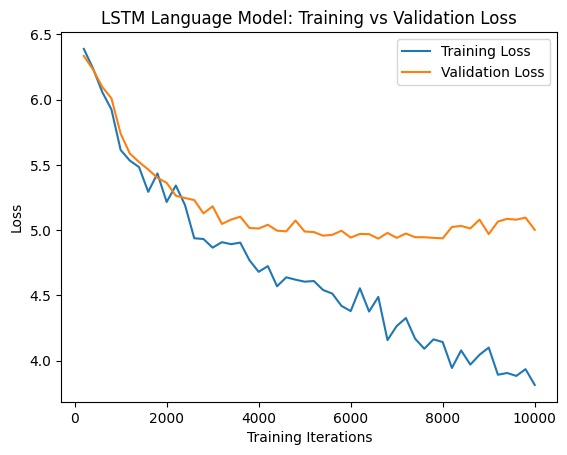

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure()
plt.plot(steps, train_losses, label="Training Loss")
plt.plot(steps, valid_losses, label="Validation Loss")
plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.title("LSTM Language Model: Training vs Validation Loss")
plt.legend()
plt.show()


#### STEP 7.6: Compute Perplexity from Loss

In [38]:
import math

# Convert loss → perplexity
train_ppl = [math.exp(l) for l in train_losses]
valid_ppl = [math.exp(l) for l in valid_losses]

print("Last Training Perplexity:", train_ppl[-1])
print("Last Validation Perplexity:", valid_ppl[-1])


Last Training Perplexity: 45.337288038512
Last Validation Perplexity: 148.77638551725704


#### STEP 7.7: Plot Training vs Validation Perplexity

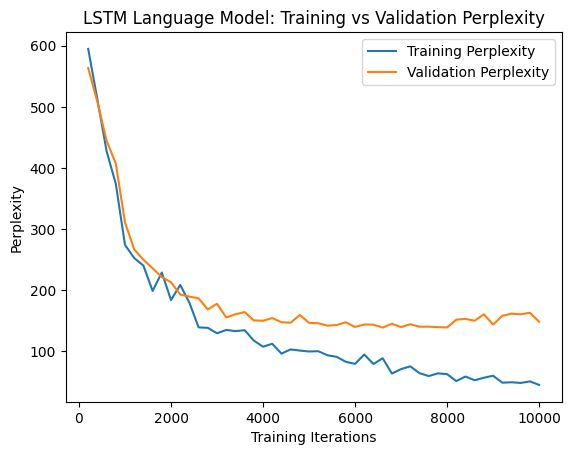

In [39]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(steps, train_ppl, label="Training Perplexity")
plt.plot(steps, valid_ppl, label="Validation Perplexity")
plt.xlabel("Training Iterations")
plt.ylabel("Perplexity")
plt.title("LSTM Language Model: Training vs Validation Perplexity")
plt.legend()
plt.show()


### STEP 8: SAVE THE TRAINED LSTM LANGUAGE MODEL
Objective

Save the trained LSTM language model to disk so it can be reloaded later for text generation without retraining.

In [40]:
import os

MODEL_DIR = "../model"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Model directory:", os.path.abspath(MODEL_DIR))


Model directory: d:\Data Science\Second Semester\NLP\Assignment\A2\model


#### STEP 8.2: Save Model Weights

In [41]:
MODEL_PATH = os.path.join(MODEL_DIR, "lstm_language_model.pt")

torch.save(model.state_dict(), MODEL_PATH)

print("Model saved to:", os.path.abspath(MODEL_PATH))


Model saved to: d:\Data Science\Second Semester\NLP\Assignment\A2\model\lstm_language_model.pt


#### STEP 8.3: (Important) Save Vocabulary Objects

In [42]:
import pickle

VOCAB_PATH = os.path.join(MODEL_DIR, "vocab.pkl")

with open(VOCAB_PATH, "wb") as f:
    pickle.dump(
        {
            "stoi": stoi,
            "itos": itos
        },
        f
    )

print("Vocabulary saved to:", os.path.abspath(VOCAB_PATH))


Vocabulary saved to: d:\Data Science\Second Semester\NLP\Assignment\A2\model\vocab.pkl


### STEP 9: LOAD THE MODEL AND GENERATE TEXT

Objective

Load the trained LSTM model + vocabulary from ../model/ and generate new text using a seed prompt.

#### STEP 9.1: Import Libraries and Set Paths

In [43]:
import os
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F

MODEL_DIR = "../model"
MODEL_PATH = os.path.join(MODEL_DIR, "lstm_language_model.pt")
VOCAB_PATH = os.path.join(MODEL_DIR, "vocab.pkl")

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)
print("Model path:", os.path.abspath(MODEL_PATH))
print("Vocab path:", os.path.abspath(VOCAB_PATH))


Device: cuda
Model path: d:\Data Science\Second Semester\NLP\Assignment\A2\model\lstm_language_model.pt
Vocab path: d:\Data Science\Second Semester\NLP\Assignment\A2\model\vocab.pkl


#### STEP 9.2: Load Vocabulary (stoi / itos)

In [46]:
with open(VOCAB_PATH, "rb") as f:
    vocab = pickle.load(f)

stoi = vocab["stoi"]
itos = vocab["itos"]

# Special token IDs
PAD = stoi.get("<pad>", 0)
UNK = stoi.get("<unk>", 1)

print("Vocabulary loaded.")
print("Vocab size:", len(itos))


Vocabulary loaded.
Vocab size: 20130


#### STEP 9.3: Re-create the Model Object

In [47]:
# STEP 9.3: Create model instance (class already defined in STEP 6.2)

emb_dim = 256
hidden_dim = 1024
num_layers = 3
dropout = 0.3




model = LSTMLanguageModel(
    vocab_size=len(itos),
    emb_dim=emb_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout,
    pad_idx=PAD
).to(device)

print("Model object created.")


Model object created.


#### STEP 9.4: Load Saved Weights into the Model

In [48]:
# STEP 9.4: Load model weights
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print("Model weights loaded and model set to eval mode.")


Model weights loaded and model set to eval mode.


In [49]:
# Create a tiny test input (use any valid token id)
x_test = torch.tensor([[stoi.get("alice", UNK)]], dtype=torch.long).to(device)

logits, _ = model(x_test)
print("Forward pass works. Logits shape:", logits.shape)

Forward pass works. Logits shape: torch.Size([1, 1, 20130])


STEP 9.5.1: Helper Functions (Tokenize → Encode → Decode)

In [57]:
import re

def word_tokenize(text: str):
    """
    Tokenize input text into words/numbers/punctuation (word-level LM tokenizer).
    Must match the tokenizer used during training.
    """
    text = text.lower()
    return re.findall(r"[a-z]+(?:'[a-z]+)?|[0-9]+|[^\w\s]", text)

def encode_tokens(tok_list):
    """Convert tokens to integer IDs using stoi. Unknown tokens -> UNK."""
    return [stoi.get(t, UNK) for t in tok_list]

def decode_tokens(tok_ids):
    """Convert integer IDs back into tokens using itos."""
    return [itos[i] for i in tok_ids]


### STEP 9.5.2: Clean Text Output

In [50]:
PUNCT_NO_SPACE_BEFORE = {".", ",", "!", "?", ";", ":", "%", ")", "]", "}"}
PUNCT_NO_SPACE_AFTER  = {"(", "[", "{"}

def detokenize(tokens):
    """
    Convert token list into readable text by fixing spaces around punctuation.
    """
    out = []
    for t in tokens:
        if not out:
            out.append(t)
            continue

        prev = out[-1]

        # No space before punctuation like ".", ",", "!"
        if t in PUNCT_NO_SPACE_BEFORE:
            out[-1] = prev + t
        # No space after opening brackets
        elif prev in PUNCT_NO_SPACE_AFTER:
            out[-1] = prev + t
        else:
            out.append(" " + t)

    return "".join(out).strip()


#### STEP 9.5.0: Add Top-K Helper Function

In [51]:
import torch
import torch.nn.functional as F

def sample_top_k(next_logits, k=30):
    """
    Sample from the top-k most likely tokens.
    
    next_logits: Tensor of shape [1, vocab_size]
    returns: Tensor of shape [1, 1] (next token id)
    """
    values, indices = torch.topk(next_logits, k)   # [1, k]
    probs = F.softmax(values, dim=-1)              # [1, k]
    choice = torch.multinomial(probs, 1)            # [1, 1]
    next_id = indices.gather(-1, choice)            # [1, 1]
    return next_id


### STEP 9.5.3: Generation Function (Temperature Sampling)

In [58]:
import torch.nn.functional as F
import torch

@torch.no_grad()
@torch.no_grad()
def generate_text(model, seed_text, max_new_tokens=100, temperature=1.0, top_k=30):
    """
    Generate text from the LSTM language model using:
    - Temperature scaling
    - Top-k sampling (more robust than full sampling)

    Parameters:
    - seed_text: starting prompt (string)
    - max_new_tokens: number of tokens to generate
    - temperature: randomness control (lower = safer)
    - top_k: sample only from the top_k most likely next tokens

    Returns:
    - generated string (detokenized)
    """
    model.eval()

    # 1) Tokenize + encode seed
    seed_tokens = word_tokenize(seed_text)
    seed_ids = encode_tokens(seed_tokens)

    if len(seed_ids) == 0:
        seed_ids = [UNK]

    # 2) Feed seed through model to build initial hidden state
    x = torch.tensor([seed_ids], dtype=torch.long).to(device)  # [1, T]
    _, state = model(x)

    generated_ids = seed_ids[:]   # start with seed
    last_id = x[:, -1:]           # last token as next input

    # 3) Generate next tokens
    for _ in range(max_new_tokens):
        logits, state = model(last_id, state)          # logits: [1, 1, V]
        next_logits = logits[:, -1, :]                 # [1, V]

        # Temperature scaling (avoid division by 0)
        if temperature is not None and temperature > 0:
            next_logits = next_logits / temperature

        # Top-k sampling (fallback to full sampling if top_k is None/too big)
        if top_k is not None and 1 <= top_k < next_logits.size(-1):
            next_id = sample_top_k(next_logits, k=top_k)
        else:
            probs = F.softmax(next_logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)  # [1, 1]

        generated_ids.append(next_id.item())
        last_id = next_id

    # 4) Decode + detokenize
    generated_tokens = decode_tokens(generated_ids)
    return detokenize(generated_tokens)


#### STEP 9.5.4: Generate Text

In [59]:
seed = "alice was"
text_out = generate_text(model, seed_text=seed, max_new_tokens=100, temperature=0.7,top_k=20)

print("=== GENERATED TEXT ===")
print(text_out)


=== GENERATED TEXT ===
alice was so communicative, that it was not much. " i think she had been at the window, " said the cat. " i want to have gone in, " said joe. " you will have come down, " said he. " i have been a little, but it is impossible to see a better answer than it is. " " i think you could not think of her. " " i am afraid of it. " " i am not going to say so. " " i must


In [60]:
checkpoint = {
    "state_dict": model.state_dict(),
    "config": {
        "vocab_size": len(itos),
        "emb_dim": emb_dim,
        "hidden_dim": hidden_dim,
        "num_layers": num_layers,
        "dropout": dropout,
        "pad_idx": PAD
    }
}
torch.save(checkpoint, MODEL_PATH)
print("Final checkpoint saved safely.")

Final checkpoint saved safely.


In [110]:
checkpoint = torch.load(
    "../model/lstm_language_model.pt",
    map_location=device
)

model.load_state_dict(checkpoint["state_dict"])

<All keys matched successfully>